 ## 1. Loading the Dataset
Air Quality Data in India (2015-2020), sourced from Kaggle (CPCB - Central Pollution Control Board). Contains daily pollutant readings across 26 Indian cities.

In [11]:
import pandas as pd

df = pd.read_csv('city_day.csv')

print(df.shape)
print(df.info())
print(df.isnull().sum())

(29531, 16)
<class 'pandas.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  str    
 1   Date        29531 non-null  str    
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  str    
dtypes: float64(13), str(3)
memory usage: 3.6 MB
None
City              0
Date              0
PM2.5          4598
PM10          11140
NO             358

## 2. Data Cleaning
Dropped the Xylene column (61% missing). Filled remaining pollutant gaps using city-wise median, with overall median as fallback. Dropped rows missing AQI/AQI_Bucket since these are calculated fields, not raw readings.

In [12]:
df = df.drop(columns=['Xylene'])
print(df.shape)

(29531, 15)


In [13]:
pollutant_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene']

for col in pollutant_cols:
    df[col] = df.groupby('City')[col].transform(lambda x: x.fillna(x.median()))

print(df.isnull().sum())

City             0
Date             0
PM2.5            0
PM10          2009
NO               0
NO2              0
NOx           1169
NH3           2009
CO               0
SO2              0
O3             162
Benzene       2732
Toluene       4010
AQI           4681
AQI_Bucket    4681
dtype: int64


In [14]:
pollutant_cols = ['PM10', 'NOx', 'NH3', 'O3', 'Benzene', 'Toluene']

for col in pollutant_cols:
    df[col] = df[col].fillna(df[col].median())

print(df.isnull().sum())

City             0
Date             0
PM2.5            0
PM10             0
NO               0
NO2              0
NOx              0
NH3              0
CO               0
SO2              0
O3               0
Benzene          0
Toluene          0
AQI           4681
AQI_Bucket    4681
dtype: int64


In [15]:
df = df.dropna(subset=['AQI', 'AQI_Bucket'])
print(df.shape)
print(df.isnull().sum())

(24850, 15)
City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
AQI           0
AQI_Bucket    0
dtype: int64


In [16]:
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

df.head()

C:\Users\Rumana\AppData\Local\Temp\ipykernel_21232\419674981.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI,AQI_Bucket,Year,Month
28,Ahmedabad,2015-01-29,83.13,107.96,6.93,28.71,33.72,14.5,6.93,49.52,59.76,0.02,0.00,209.0,Poor,2015,1
29,Ahmedabad,2015-01-30,79.84,107.96,13.85,28.68,41.08,14.5,13.85,48.49,97.07,0.04,0.00,328.0,Very Poor,2015,1
30,Ahmedabad,2015-01-31,94.52,107.96,24.39,32.66,52.61,14.5,24.39,67.39,111.33,0.24,0.01,514.0,Severe,2015,1
31,Ahmedabad,2015-02-01,135.99,107.96,43.48,42.08,84.57,14.5,43.48,75.23,102.70,0.40,0.04,782.0,Severe,2015,2
32,Ahmedabad,2015-02-02,178.33,107.96,54.56,35.31,72.80,14.5,54.56,55.04,107.38,0.46,0.06,914.0,Severe,2015,2


In [17]:
city_aqi = df.groupby('City')['AQI'].mean().sort_values(ascending=False)
print(city_aqi)

City
Ahmedabad             452.122939
Delhi                 259.487744
Patna                 240.782042
Gurugram              225.123882
Lucknow               217.973059
Talcher               172.886819
Jorapokhar            159.251621
Brajrajnagar          150.280505
Kolkata               140.566313
Guwahati              140.111111
Jaipur                133.679159
Bhopal                132.827338
Amritsar              119.920959
Visakhapatnam         117.269855
Chennai               114.502654
Hyderabad             109.207447
Mumbai                105.352258
Kochi                 104.284810
Chandigarh             96.498328
Amaravati              95.299643
Bengaluru              94.318325
Ernakulam              92.359477
Thiruvananthapuram     75.878327
Coimbatore             73.023256
Shillong               53.795122
Aizawl                 34.765766
Name: AQI, dtype: float64


 ## 3. Most Polluted Cities
Comparing average AQI across cities to identify India's most polluted regions.

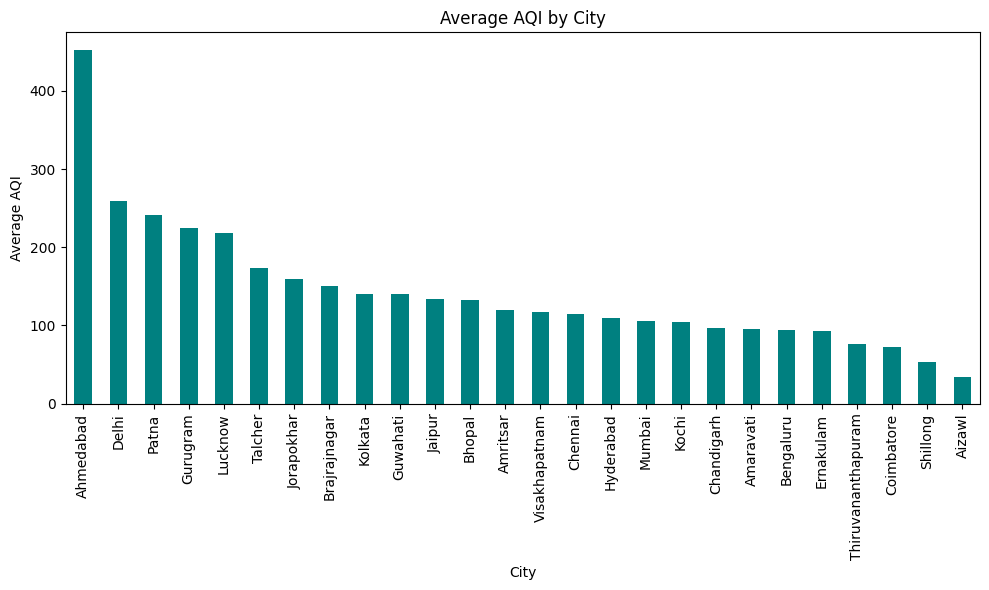

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
city_aqi.plot(kind='bar', color='teal')
plt.title('Average AQI by City')
plt.xlabel('City')
plt.ylabel('Average AQI')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## 4. AQI Trend Over Years (2015-2020)
Tracking how average AQI changed nationally year by year.

Year
2015    212.463054
2016    197.150019
2017    181.472789
2018    182.684312
2019    156.518173
2020    113.520697
Name: AQI, dtype: float64


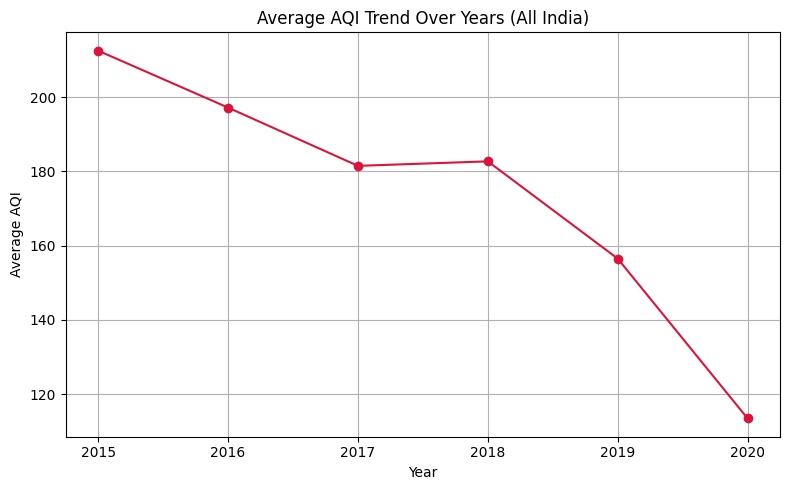

In [20]:
yearly_aqi = df.groupby('Year')['AQI'].mean()
print(yearly_aqi)

plt.figure(figsize=(8,5))
yearly_aqi.plot(kind='line', marker='o', color='crimson')
plt.title('Average AQI Trend Over Years (All India)')
plt.xlabel('Year')
plt.ylabel('Average AQI')
plt.grid(True)
plt.tight_layout()
plt.show()

## 5. COVID Lockdown Effect (2020)
Breaking down 2020 by month to check if India's lockdown improved air quality.

Month
1    168.486563
2    158.036466
3    110.177267
4     86.718056
5     87.446292
6     76.214674
7     72.500000
Name: AQI, dtype: float64


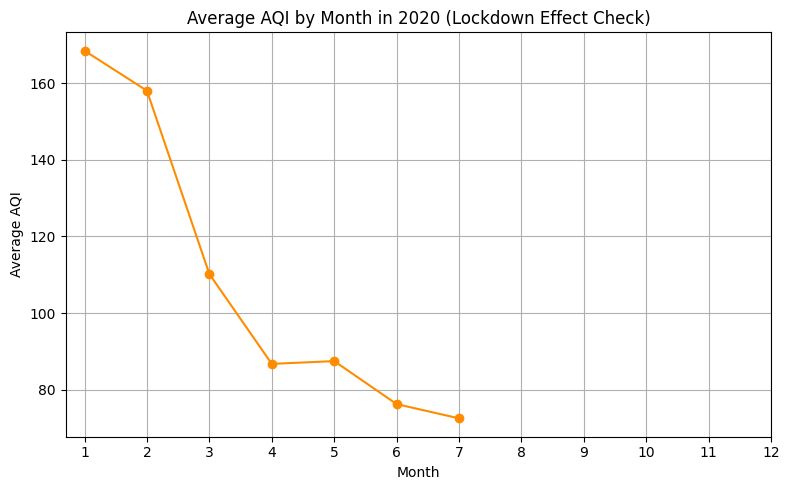

In [21]:
aqi_2020 = df[df['Year'] == 2020].groupby('Month')['AQI'].mean()
print(aqi_2020)

plt.figure(figsize=(8,5))
aqi_2020.plot(kind='line', marker='o', color='darkorange')
plt.title('Average AQI by Month in 2020 (Lockdown Effect Check)')
plt.xlabel('Month')
plt.ylabel('Average AQI')
plt.xticks(range(1,13))
plt.grid(True)
plt.tight_layout()
plt.show()

## 6. Seasonal Pollution Patterns
Average AQI by month across all years, to identify India's pollution season.

Month
1     231.674918
2     202.905197
3     164.735281
4     143.355120
5     135.489579
6     120.198379
7     111.854575
8     113.613176
9     115.191804
10    188.613552
11    241.681302
12    227.084980
Name: AQI, dtype: float64


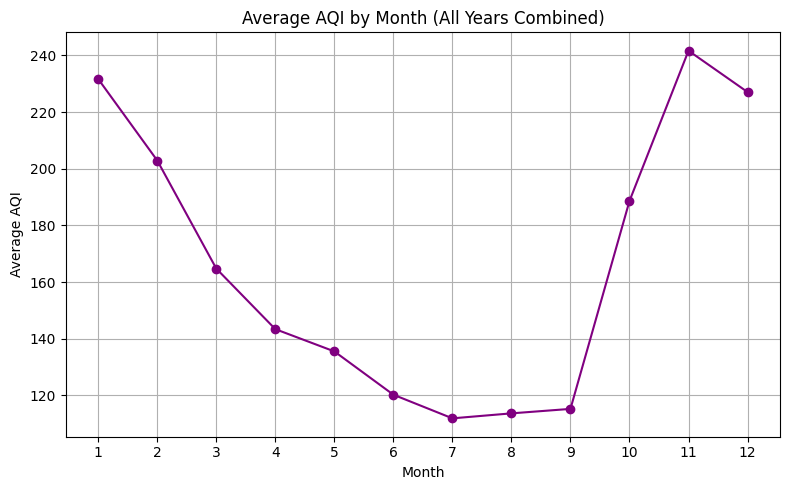

In [22]:
monthly_aqi = df.groupby('Month')['AQI'].mean()
print(monthly_aqi)

plt.figure(figsize=(8,5))
monthly_aqi.plot(kind='line', marker='o', color='purple')
plt.title('Average AQI by Month (All Years Combined)')
plt.xlabel('Month')
plt.ylabel('Average AQI')
plt.xticks(range(1,13))
plt.grid(True)
plt.tight_layout()
plt.show()

## 7. Pollutant Correlations
Which pollutants rise and fall together, and which most strongly influence overall AQI.

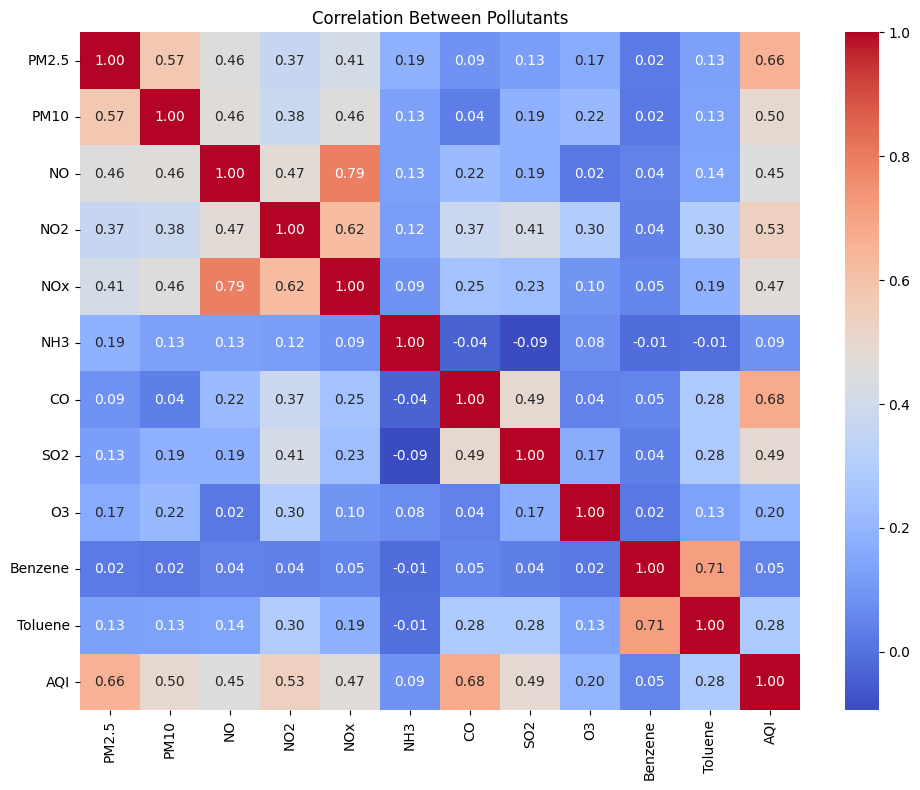

In [23]:
import seaborn as sns

pollutants = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'AQI']
corr = df[pollutants].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Pollutants')
plt.tight_layout()
plt.show()